In [50]:
import numpy as np
import pandas as pd

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import string
from gensim.models import Word2Vec
from sklearn.cluster import KMeans

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

import matplotlib.pyplot as plt
%matplotlib inline

import plotly.express as px
from sklearn.decomposition import PCA


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/laurenshores/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/laurenshores/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/laurenshores/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [51]:
dff = pd.read_csv("AmzingRceTeams_Data.csv")

In [52]:
dff.shape

(313, 34)

In [53]:
def preprocess(text):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    tokens = word_tokenize(text.lower())
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return ' '.join(tokens)

dff['cleaned_occupation_x'] = dff['Occupation_x'].apply(preprocess)
dff['cleaned_occupation_y'] = dff['Occupation_y'].apply(preprocess)

In [54]:
dff.columns

Index(['Age_x', 'Age_y', 'LGBT_team', 'AficanAm_team', 'Friend_team',
       'Family_team', 'Stranger_team', 'Female_team', 'Male_team', 'Coed_team',
       'AsianAm_team', 'Married_team', 'Disabled_team', 'Hispanic_team',
       'Couple_or_Ex_team', 'Interracial_team', 'RealityShow_team', 'Season',
       'RPlace', 'Name_x', 'Name_y', 'Hometown_x', 'Hometown_y', 'Avg_Age',
       'Age_Diff', 'State_x', 'State_y', 'Same_State', 'Occupation_x',
       'Occupation_y', 'profile_txt', 'profile_txt2', 'Top_3', 'Y',
       'cleaned_occupation_x', 'cleaned_occupation_y'],
      dtype='object')

In [55]:
dff.head()

,Age_x,Age_y,LGBT_team,AficanAm_team,Friend_team,Family_team,Stranger_team,Female_team,Male_team,Coed_team,...,State_y,Same_State,Occupation_x,Occupation_y,profile_txt,profile_txt2,Top_3,Y,cleaned_occupation_x,cleaned_occupation_y
0,28,28,0,0,0,0,0,0,0,0,...,Connecticut,True,Military folk,Military folk,"[""I'd most like to receive a letter from: Nobo...",['no profile info'],0,0,military folk,military folk
1,28,27,0,0,1,0,0,1,0,0,...,Texas,True,Teachers,Teachers,"[""I'd most like to receive a letter from: Caro...",['no profile info'],0,0,teacher,teacher
2,43,42,0,0,1,0,0,1,0,0,...,Maryland,False,Missing,Missing,"[""I'd most like to receive a letter from: My k...",['no profile info'],0,0,missing,missing
3,65,60,0,0,0,0,0,0,0,1,...,Texas,True,Air Force Pilot,Retired,"[""I'd most like to receive a letter from: My k...",['no profile info'],0,0,air force pilot,retired
4,32,27,0,0,0,0,0,0,0,1,...,California,True,Actor,Bartender,"[""I'd most like to receive a letter from: Brot...",['no profile info'],0,0,actor,bartender


# Old way of Handling Occupations

Originally, I thought I would use word2Vec on my occupation text data to train a model. The point is to get word embeddings (meaningful vector representations) of these words. However, after inspecting the initial model, when I looked in 2D space at the vectors, the place in space did not make sense.

I decided that there were not enough data or context to train W2V model that would make any sense. So I decided to fine tune a pre-trained model.

In [56]:
# combine both columns of occupations to train word2vec model
occs = pd.concat([dff['cleaned_occupation_x'], dff['cleaned_occupation_y']])

# word tokens for each row in a list
z = [row.split() for row in occs]
# combine the list of lists of tokens per row into one list
occs1 = set(sum(z, []))

# Train Word2Vec model on the preprocessed occupation names
model = Word2Vec(sentences=[row.split() for row in occs], vector_size=300, window=3, min_count=1, workers=4)


In [57]:
print(len(list(occs)))
set(list(occs))
z = [row.split() for row in occs]

print(# combine the list of lists of tokens per row into one list
len(set(sum(z, []))))

626
475


In [58]:
# Fine Tuning pre-trained model to try to get better representations

from gensim.models import KeyedVectors

# Load pre-trained Word2Vec model (e.g., Google News vectors)
pretrained_model_path = 'GoogleNews-vectors-negative300.bin'
pretrained_model = KeyedVectors.load_word2vec_format(pretrained_model_path, binary=True)

# Fine-tune on domain-specific data
#model.build_vocab(occs, update=True)
#model.train(occs, total_examples=model.corpus_count, epochs=model.epochs)

# Intersect the pre-trained vectors with the new model's vocabulary
model.build_vocab([list(pretrained_model.key_to_index.keys())], update=True)

# Copy weights from the pre-trained model
model.wv.vectors_lockf = np.ones(len(model.wv), dtype=np.float32)  # Lock factor to protect weights from being overwritten
model.wv.intersect_word2vec_format(pretrained_model_path, binary=True, lockf=1.0)

# Train on new data
model.train(occs, total_examples=model.corpus_count, epochs=model.epochs)


FileNotFoundError: [Errno 2] No such file or directory: 'GoogleNews-vectors-negative300.bin'

In [ ]:
# I want to plot the vectors and see how they relate to each other on a two dimensional plane

from sklearn.manifold import TSNE

# Extract word vectors and their labels
word_vectors = []
word_labels = []
nic = 0
nic_list = []

uni_words = occs1#set(list(occs))
print('length of unique words: ' + str(len(uni_words)))
for word in uni_words:
    try:
        word_vectors.append(model.wv[word])
        word_labels.append(word)
    except:
        #print("not in corpus")
        nic = nic+1
        nic_list.append(word)

print("not in corpus count: " + str(nic))
# Convert to numpy array
word_vectors = np.array(word_vectors)

word_vectors = word_vectors[0:100]
word_labels = word_labels[0:100]

# Perform t-SNE to reduce to 2D
tsne = TSNE(n_components=2, random_state=42)
word_vectors_2d = tsne.fit_transform(word_vectors)


# Plot the t-SNE results
plt.figure(figsize=(10, 10))
plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], c='blue')

# Annotate each point with its corresponding word label
for i, label in enumerate(word_labels):
    plt.annotate(label, (word_vectors_2d[i, 0:1], word_vectors_2d[i, 1:2]))

plt.title('Word2Vec word embeddings visualization using t-SNE')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.show()

In [ ]:
# Calculate the average word vector for each occupation (because an occupation may consist of more than one word (vector))
def get_average_vector(text, model):
    words = text.split()
    word_vectors = [model.wv[word] for word in words if word in model.wv]
    if not word_vectors:
        return np.zeros(model.vector_size)
    return np.mean(word_vectors, axis=0)

dff['occ_vecs_x'] = dff['cleaned_occupation_x'].apply(lambda x: get_average_vector(x, model))
dff['occ_vecs_y'] = dff['cleaned_occupation_y'].apply(lambda x: get_average_vector(x, model))

In [ ]:
# Convert the vector column into a numpy array
vectors_x = np.array(dff['occ_vecs_x'].tolist())
vectors_y = np.array(dff['occ_vecs_y'].tolist())

#vectors

In [ ]:
# Perform K-means clustering
"""
num_clusters = 4  # Define the number of clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
cluster = kmeans.fit_predict(vectors)
cluster
"""

In [ ]:
def elbow_fun(data):
    kmeans_kwargs = {
        "init": "random",
        "n_init": 10,
        "max_iter": 300,
        "random_state": 42,
    }

    # A list holds the SSE values for each k
    sse = []
    for k in range(1, 50):
        kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
        kmeans.fit(data)
        sse.append(kmeans.inertia_)

    plt.style.use("fivethirtyeight")
    plt.plot(range(1, 50), sse)
    plt.xticks(range(1, 50))
    plt.xlabel("Number of Clusters")
    plt.ylabel("SSE")
    
    return plt.show()

def kmeans_fun(n_clus, data):
    # Perform k-means clustering
    kmeans = KMeans(n_clusters=n_clus)
    kmeans.fit(data)
    return kmeans

def plot_2comp_target(data, target):
    """target is the variable whose color we want to see. Could be cluster labels or Y var, etc"""

    pca = PCA(n_components=2)
    components = pca.fit_transform(data)

    fig = px.scatter(components, x=0, y=1, color=target)
    return fig.show()

def plot_comp_variability(data, target):
    """# viz all the components
    target is the variable whose color we want to see. Could be cluster labels or Y var, etc"""
    
    pca = PCA()
    components = pca.fit_transform(data)
    labels = {
        str(i): f"PC {i+1} ({var:.1f}%)"
        for i, var in enumerate(pca.explained_variance_ratio_ * 100)
    }

    fig = px.scatter_matrix(
        components,
        labels=labels,
        dimensions=range(4),
        color=target
    )
    fig.update_traces(diagonal_visible=False)
    return fig.show()


In [ ]:
elbow_fun(vectors_x)

In [ ]:
kmeans_x = kmeans_fun(7, vectors_x)
kmeans_y = kmeans_fun(7, vectors_y)
# Get cluster labels
cluster_labels_x = kmeans_x.labels_
cluster_labels_y = kmeans_y.labels_

plot_2comp_target(vectors_x, dff['Y'])
plot_comp_variability(vectors_x, cluster_labels_x)

In [ ]:
pca = PCA(n_components=2)
components = pca.fit_transform(vectors_x)

fig = px.scatter(components, x=0, y=1, color=cluster_labels_x)
fig.show()

# New Way of Handling Occupation (Occupation Outlook Handbook)

This approach is to use the word2vec embeddings that were trained on the OOH in the model.
Thus we have to map the occupations in the amazing race dataset to those in the OOH.
there were many non-matches so ended up converting both to embeddings using transformers and using cosine similarity to find the best match in the OOH to that of the AR dataset.

In [59]:
model = Word2Vec.load("~/Documents/Data_Science_Projects/Amazing_Race/000_AmazingRaceAnalysis_and_Modeling/occupation_word2vec.model")


In [60]:
# Get word embeddings
words = list(model.wv.index_to_key)  # Get vocabulary
word_vectors = np.array([model.wv[word] for word in words])  # Get vectors


In [61]:
# see if ar occs are in model words list
ar_occs = list(set(list(dff['cleaned_occupation_x']) + list(dff['cleaned_occupation_y'])))

# occs that are present in word2vec model. Eventually create a dictionary to map amazing race occs to something in the model
occs_present = [i for i in ar_occs if i in words ]

#print(len(ar_occs))

occs_not_present = [i for i in ar_occs if i not in words ]

In [62]:
def find_partial_matches(list1, list2):
    matches = {}
    for item1 in list1:
        matched_items = [item2 for item2 in list2 if item1 in item2]
        matches[item1] = matched_items
    return matches


# Find matches
result = find_partial_matches(occs_not_present[1:], words)
'''
# Print results
for key, value in result.items():
    print(f"{key}: {value}")
    print("------------")
    print("\n")
'''
# nothing is matching! Will try to account for matching chunks of words

'\n# Print results\nfor key, value in result.items():\n    print(f"{key}: {value}")\n    print("------------")\n    print("\n")\n'

In [63]:
def find_partial_matches(list1, list2, separator=" "):
    matches = {}
    for item1 in list1:
        chunks = item1.split(separator)  # Split into natural chunks
        matched_items = [item2 for item2 in list2 if any(chunk in item2 for chunk in chunks)]
        matches[item1] = matched_items
    return matches


# Find matches
result = find_partial_matches(occs_not_present[1:], words, separator=" ")
'''
# Print results
for key, value in result.items():
    print(f"{key}: {value}")
    print("--------------------")
    print("\n")
    '''
# matches not great, and there are too many!

'\n# Print results\nfor key, value in result.items():\n    print(f"{key}: {value}")\n    print("--------------------")\n    print("\n")\n    '

In [64]:
def best_partial_match(list1, list2, separator=" "):
    best_matches = {}

    for item1 in list1:
        chunks = item1.split(separator)  # Split into meaningful parts
        match_scores = {}

        for item2 in list2:
            # Count how many chunks from item1 appear in item2
            match_count = sum(1 for chunk in chunks if chunk in item2)
            
            # Calculate overlap length
            overlap_length = sum(len(chunk) for chunk in chunks if chunk in item2)

            # Score: Prioritize match count, then overlap length
            match_scores[item2] = (match_count, overlap_length)

        # Select the best match: highest match count, then longest overlap
        best_match = max(match_scores, key=lambda x: match_scores[x], default=None)

        best_matches[item1] = best_match

    return best_matches

# Example lists
list1 = ["apple_pie", "banana_bread", "cherry tart"]
list2 = ["apple sauce", "banana smoothie", "cherry pie", "grape juice", "tart cherry"]

# Find best matches
result = best_partial_match(occs_not_present[1:], words, separator=" ")
'''
# Print results
for key, value in result.items():
    print(f"{key}: {value}")
    print("--------------------")
    print("\n")
'''

# ok, have narrowed down to 1 match. But by trying to capture number of matching characters, meaning is definitely getting lost. 
# Try transformers to match by semantic meaning. Closesness using cosine similarity

'\n# Print results\nfor key, value in result.items():\n    print(f"{key}: {value}")\n    print("--------------------")\n    print("\n")\n'

In [65]:
#%pip install sentence_transformers
from sentence_transformers import SentenceTransformer, util

def best_semantic_match(list1, list2, model_name="all-MiniLM-L6-v2"):
    model = SentenceTransformer(model_name)

    # Encode all items into embeddings
    list1_embeddings = model.encode(list1, convert_to_tensor=True)
    list2_embeddings = model.encode(list2, convert_to_tensor=True)

    best_matches = {}

    for i, item1 in enumerate(list1):
        # Compute cosine similarity between item1 and all items in list2
        similarities = util.pytorch_cos_sim(list1_embeddings[i], list2_embeddings)[0]

        # Find the best match (highest similarity)
        best_match_idx = similarities.argmax().item()
        best_matches[item1] = list2[best_match_idx]

    return best_matches

# Example lists
list1 = ["apple pie", "banana bread", "cherry tart"]
list2 = ["apple sauce", "banana smoothie", "cherry pie", "grape juice", "tart cherry"]

# Find best matches
result = best_semantic_match(occs_not_present[1:], words)




# Note: these bert embeddings worked so well, it seems silly to go on with harnessing the word2vec embeddings for the modeling part

In [66]:
# Use dictionary to translate ar occs to those in the word2vec model
lstx=[]
for i in dff['cleaned_occupation_x']:
    try:
        lstx.append(result[i])
    except:
        lstx.append(i)

lsty=[]
for i in dff['cleaned_occupation_y']:
    try:
        lsty.append(result[i])
    except:
        lsty.append(i)
dff['ooh_x'] = lstx
dff['ooh_y'] = lsty

In [67]:
ooh_w2v_dic = {}
for i in range(len(words)):
    word = words[i]
    vec = word_vectors[i]
    ooh_w2v_dic[word] = vec

In [68]:
# Use dictionary to translate ar occs to those in the word2vec model
w2vx=[]
for i in dff['ooh_x']:
    try:
        w2vx.append(ooh_w2v_dic[i])
    except:
        w2vx.append(i)

w2vy=[]
for i in dff['ooh_y']:
    try:
        w2vy.append(ooh_w2v_dic[i])
    except:
        w2vy.append(i)
dff['w2v_x'] = w2vx
dff['w2v_y'] = w2vy

In [69]:
#had some errors about the length of my w2v embeddings

# Check the lengths of each row in 'w2v_x'
lengths = [len(x) if isinstance(x, list) else 0 for x in dff['w2v_x']]
print(set(lengths))  # This should return only one value (e.g., {300})
print(dff['w2v_x'].head(10))  # View first 10 entries
print(dff['w2v_x'].apply(type).value_counts())  # Check data types in column
print(dff['w2v_x'].isna().sum())  # Count NaNs


{0}
0    [-0.10531246, 0.18211466, 0.11748633, -0.02699...
1    [-0.15964134, 0.25576538, 0.167509, -0.0357637...
2    [-0.028484693, 0.022923531, 0.026052989, -0.00...
3    [-0.08287925, 0.14618975, 0.083862305, -0.0208...
4    [-0.07029149, 0.12248993, 0.07417071, -0.01479...
5    [-0.09095938, 0.16138147, 0.121156566, -0.0232...
6    [-0.08213141, 0.16172348, 0.12433711, -0.04729...
7    [-0.028484693, 0.022923531, 0.026052989, -0.00...
8    [-0.09095938, 0.16138147, 0.121156566, -0.0232...
9    [-0.018985456, 0.042151205, 0.026618494, -0.00...
Name: w2v_x, dtype: object
w2v_x
<class 'numpy.ndarray'>    297
<class 'str'>               16
Name: count, dtype: int64
0


In [70]:
#there are some string classes in my embeddings? What do they look like?
[i for i in dff['w2v_x'] if type(i) == str]


['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']

In [71]:
# replace with 0 vectors of correct length

desired_length = 100  # Adjust to your embedding size
zero_vector = [0.0] * desired_length

def fix_embedding(x):
    if isinstance(x, list) and len(x) == desired_length:
        return x  # Keep valid embeddings
    elif isinstance(x, np.ndarray) and x.shape[0] == desired_length:
        return x.tolist()  # Convert NumPy arrays to lists
    else:
        return zero_vector  # Replace None, NaN, or incorrect shapes

dff['w2v_x'] = dff['w2v_x'].apply(fix_embedding)
dff['w2v_y'] = dff['w2v_y'].apply(fix_embedding)


In [72]:
ooh_dat = pd.read_csv("OOH_clean.csv")

In [73]:
ooh_dat.head(2)

,Unnamed: 0,/occupation/occupation_name_short_singular,/occupation/quick_facts/qf_median_pay_annual/value,/occupation/what_they_do/section_body,/occupation/how_to_become_one/section_body,/occupation/summary_work_environment,/occupation/similar_occupations/section_body
0,0,Accountant or Auditor,79880.0,Accountants and auditors prepare and examine f...,Accountants and auditors typically need at lea...,Most accountants and auditors work full time. ...,"accountants and auditors. Bookkeeping, acco..."
1,1,Actor,NaN,Actors express ideas and portray characters in...,Actors typically enhance their skills through ...,"Actors work in various settings, including pro...",actors. Announcers present news and sports ...


## Creating Cluster Features from Occupations

In [74]:
def kmeans_fun(n_clus, data):
    # Perform k-means clustering
    kmeans = KMeans(n_clusters=n_clus)
    kmeans.fit(data)
    return kmeans
def plot_2comp_target(data, target):
    """target is the variable whose color we want to see. Could be cluster labels or Y var, etc"""

    pca = PCA(n_components=2)
    components = pca.fit_transform(data)

    fig = px.scatter(components, x=0, y=1, color=target)
    return fig.show()

def plot_comp_variability(data, target):
    """# viz all the components
    target is the variable whose color we want to see. Could be cluster labels or Y var, etc"""
    
    pca = PCA()
    components = pca.fit_transform(data)
    labels = {
        str(i): f"PC {i+1} ({var:.1f}%)"
        for i, var in enumerate(pca.explained_variance_ratio_ * 100)
    }

    fig = px.scatter_matrix(
        components,
        labels=labels,
        dimensions=range(4),
        color=target
    )
    fig.update_traces(diagonal_visible=False)
    return fig.show()


In [75]:
# Convert the vector column into a numpy array
vectors_x = np.array(dff['w2v_x'].tolist())
vectors_y = np.array(dff['w2v_y'].tolist())

kmeans_x = kmeans_fun(6, vectors_x)
kmeans_y = kmeans_fun(6, vectors_y)
# Get cluster labels
cluster_labels_x = kmeans_x.labels_
cluster_labels_y = kmeans_y.labels_

/Users/laurenshores/Documents/Data_Science_Projects/newenv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/Users/laurenshores/Documents/Data_Science_Projects/newenv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



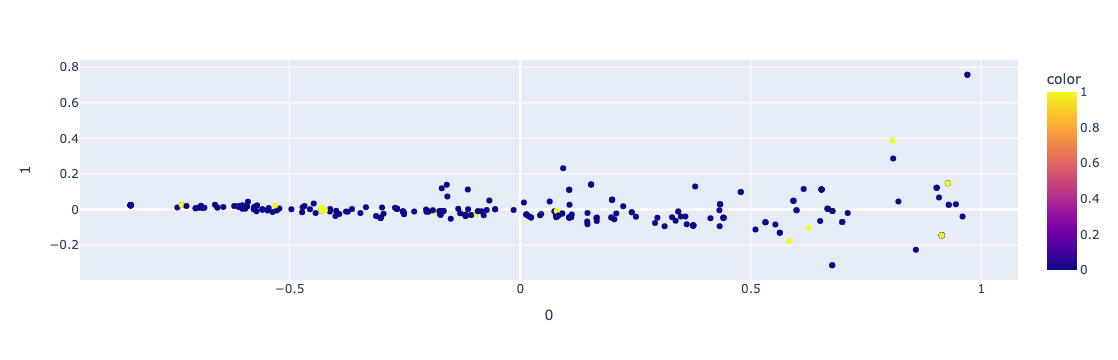

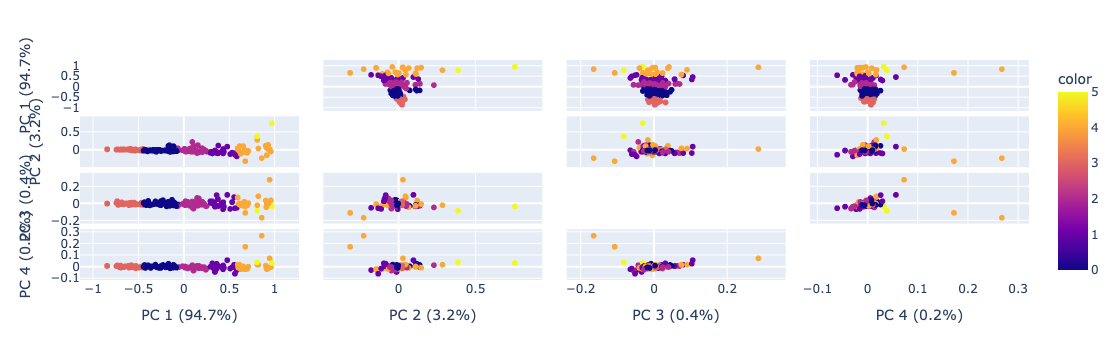

In [76]:
plot_2comp_target(vectors_x, dff['Y'])
plot_comp_variability(vectors_x, cluster_labels_x)

# BERT for Handling Occupations 

Here I convert the dataset occupations to embeddings using transformers. The OOH is not involved.

In [77]:
from sentence_transformers import SentenceTransformer, util

In [78]:
'''
def best_semantic_match(list1, list2, model_name="all-MiniLM-L6-v2"):
    model = SentenceTransformer(model_name)

    # Encode all items into embeddings
    list1_embeddings = model.encode(list1, convert_to_tensor=True)
    list2_embeddings = model.encode(list2, convert_to_tensor=True)

    best_matches = {}

    for i, item1 in enumerate(list1):
        # Compute cosine similarity between item1 and all items in list2
        similarities = util.pytorch_cos_sim(list1_embeddings[i], list2_embeddings)[0]

        # Find the best match (highest similarity)
        best_match_idx = similarities.argmax().item()
        best_matches[item1] = list2[best_match_idx]

    return best_matches


# Find best matches
result = best_semantic_match(occs_not_present[1:], words)
'''

'\ndef best_semantic_match(list1, list2, model_name="all-MiniLM-L6-v2"):\n    model = SentenceTransformer(model_name)\n\n    # Encode all items into embeddings\n    list1_embeddings = model.encode(list1, convert_to_tensor=True)\n    list2_embeddings = model.encode(list2, convert_to_tensor=True)\n\n    best_matches = {}\n\n    for i, item1 in enumerate(list1):\n        # Compute cosine similarity between item1 and all items in list2\n        similarities = util.pytorch_cos_sim(list1_embeddings[i], list2_embeddings)[0]\n\n        # Find the best match (highest similarity)\n        best_match_idx = similarities.argmax().item()\n        best_matches[item1] = list2[best_match_idx]\n\n    return best_matches\n\n\n# Find best matches\nresult = best_semantic_match(occs_not_present[1:], words)\n'

In [79]:
'''from sentence_transformers import SentenceTransformer, util

# Use transformer to convert occupations to embeddings

# list of occupations in dataset
ar_occs = list(set(list(dff['cleaned_occupation_x']) + list(dff['cleaned_occupation_y'])))



ar_occ_embeddings = model.encode(ar_occs, convert_to_tensor=True)

bert_dic = {}
for i in range(len(ar_occs)):
    occ1 = ar_occs[i]
    emb = ar_occ_embeddings[i]
    bert_dic[occ1] = emb


#384 is len of embeddings'''

"from sentence_transformers import SentenceTransformer, util\n\n# Use transformer to convert occupations to embeddings\n\n# list of occupations in dataset\nar_occs = list(set(list(dff['cleaned_occupation_x']) + list(dff['cleaned_occupation_y'])))\n\n\n\nar_occ_embeddings = model.encode(ar_occs, convert_to_tensor=True)\n\nbert_dic = {}\nfor i in range(len(ar_occs)):\n    occ1 = ar_occs[i]\n    emb = ar_occ_embeddings[i]\n    bert_dic[occ1] = emb\n\n\n#384 is len of embeddings"

In [80]:
# Use transformer to convert occupations to embeddings

# list of occupations in dataset
ar_occs = list(set(list(dff['cleaned_occupation_x']) + list(dff['cleaned_occupation_y'])))

model = SentenceTransformer("all-MiniLM-L6-v2")

def get_embeddings(text_list):
    """
    Converts a list of unique strings into semantic embeddings.
    Args: text_list (list): List of strings to embed.
    Returns: np.ndarray: Array of shape (num_texts, embedding_dim) with embeddings.
    """
    embeddings = model.encode(text_list, convert_to_numpy=True, normalize_embeddings=True)
    
    return embeddings


# Convert to embeddings
embeddings = get_embeddings(ar_occs)

print("Embedding Shape:", embeddings.shape)  # (num_texts, embedding_dim)

bert_dic = {}
for i in range(len(ar_occs)):
    occ1 = ar_occs[i]
    emb = embeddings[i]
    bert_dic[occ1] = emb

Embedding Shape: (421, 384)


In [81]:
# Use dictionary to translate ar occs to embeddings in transformer model
bertx=[]
for i in dff['cleaned_occupation_x']:
    try:
        bertx.append(bert_dic[i])
    except:
        bertx.append(i)

berty=[]
for i in dff['cleaned_occupation_y']:
    try:
        berty.append(bert_dic[i])
    except:
        berty.append(i)
dff['bert_x'] = bertx
dff['bert_y'] = berty


#This isn't enough. Need to do the cosine similarity to find the 
#similar words to the words that are in the amazing race data to then convert to vectos

# Income as a Feature?

In [82]:
import re
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

* clean up the job titles from ooh dataset
* match each occ string from ooh to a string in the amazing race dataset (create a dic) {ar_occ : ooh_occ }
* match each occ to annual pay {ooh_occ : pay}

In [83]:
ooh_dat = pd.read_csv("OOH_clean.csv")

In [84]:
ooh_dat.head(2)

,Unnamed: 0,/occupation/occupation_name_short_singular,/occupation/quick_facts/qf_median_pay_annual/value,/occupation/what_they_do/section_body,/occupation/how_to_become_one/section_body,/occupation/summary_work_environment,/occupation/similar_occupations/section_body
0,0,Accountant or Auditor,79880.0,Accountants and auditors prepare and examine f...,Accountants and auditors typically need at lea...,Most accountants and auditors work full time. ...,"accountants and auditors. Bookkeeping, acco..."
1,1,Actor,NaN,Actors express ideas and portray characters in...,Actors typically enhance their skills through ...,"Actors work in various settings, including pro...",actors. Announcers present news and sports ...


In [85]:
median_salary = 43289 #according to internet
ooh_dat['/occupation/quick_facts/qf_median_pay_annual/value'] = ooh_dat['/occupation/quick_facts/qf_median_pay_annual/value'].fillna(median_salary)

In [86]:
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation and special chars
    tokens = word_tokenize(text)  # Tokenize words
    tokens = [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords
    
    # Convert plural words to singular using lemmatization
    tokens = [lemmatizer.lemmatize(word, wordnet.NOUN) for word in tokens]

    tokens = " ".join(tokens)
    
    return tokens

# Apply preprocessing to all job descriptions
ooh_jobs = [clean_text(text) for text in ooh_dat['/occupation/occupation_name_short_singular'] ]

In [87]:
ooh_dat['clean_occ'] = ooh_jobs

In [88]:
clean_ar = list(set(list(dff['ooh_x']) + list(dff['ooh_y'])))
ar_ooh_dic = best_semantic_match(clean_ar, ooh_jobs)

In [89]:
ooh_pay_dic = dict(zip(ooh_dat['clean_occ'], ooh_dat['/occupation/quick_facts/qf_median_pay_annual/value']))

In [90]:
x_pay = [ooh_pay_dic[ar_ooh_dic[i]] for i in dff['ooh_x']]

y_pay = [ooh_pay_dic[ar_ooh_dic[i]] for i in dff['ooh_y']]

dff['x_pay'] = x_pay
dff['y_pay'] = y_pay
dff['team_pay'] = dff['x_pay'] + dff['y_pay']

In [91]:
dff.head(3)

,Age_x,Age_y,LGBT_team,AficanAm_team,Friend_team,Family_team,Stranger_team,Female_team,Male_team,Coed_team,...,cleaned_occupation_y,ooh_x,ooh_y,w2v_x,w2v_y,bert_x,bert_y,x_pay,y_pay,team_pay
0,28,28,0,0,0,0,0,0,0,0,...,military folk,military,military,"[-0.10531245917081833, 0.18211466073989868, 0....","[-0.10531245917081833, 0.18211466073989868, 0....","[-0.010797519, 0.008257406, 0.03776588, 0.0104...","[-0.010797519, 0.008257406, 0.03776588, 0.0104...",43289.0,43289.0,86578.0
1,28,27,0,0,1,0,0,1,0,0,...,teacher,teacher,teacher,"[-0.1596413403749466, 0.2557653784751892, 0.16...","[-0.1596413403749466, 0.2557653784751892, 0.16...","[-0.052863646, 0.028451515, -0.010796667, 0.06...","[-0.052863646, 0.028451515, -0.010796667, 0.06...",65220.0,65220.0,130440.0
2,43,42,0,0,1,0,0,1,0,0,...,missing,missing,missing,"[-0.02848469279706478, 0.022923531010746956, 0...","[-0.02848469279706478, 0.022923531010746956, 0...","[-0.01666675, 0.027315557, -0.0033323164, 0.09...","[-0.01666675, 0.027315557, -0.0033323164, 0.09...",47430.0,47430.0,94860.0


# Modeling with Word Embeddings

In [92]:
#%pip install imblearn
#%pip install xgboost

from sklearn.metrics import classification_report

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
#import graphviz

import imblearn
from sklearn.model_selection import train_test_split
from sklearn import metrics

from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedStratifiedKFold
from imblearn.pipeline import Pipeline

import xgboost as xgb

In [93]:


#import sklearn
#print(sklearn.__version__)

In [94]:
# Making some other features

dff['Avg_Age'] = np.mean([dff['Age_x'], dff['Age_y']],axis=0)
dff['Age_Diff'] = abs(dff['Age_x'] - dff['Age_y'])

# Do winners come from a particular state?
# is it better if both people are from the same state?
dff['State_x'] = dff.Hometown_x.apply(lambda x: x.split(",")[1])
dff['State_y'] = dff.Hometown_y.apply(lambda x: x.split(",")[1])
dff['Same_State'] = dff['State_x'] == dff['State_y']

dff.columns

Index(['Age_x', 'Age_y', 'LGBT_team', 'AficanAm_team', 'Friend_team',
       'Family_team', 'Stranger_team', 'Female_team', 'Male_team', 'Coed_team',
       'AsianAm_team', 'Married_team', 'Disabled_team', 'Hispanic_team',
       'Couple_or_Ex_team', 'Interracial_team', 'RealityShow_team', 'Season',
       'RPlace', 'Name_x', 'Name_y', 'Hometown_x', 'Hometown_y', 'Avg_Age',
       'Age_Diff', 'State_x', 'State_y', 'Same_State', 'Occupation_x',
       'Occupation_y', 'profile_txt', 'profile_txt2', 'Top_3', 'Y',
       'cleaned_occupation_x', 'cleaned_occupation_y', 'ooh_x', 'ooh_y',
       'w2v_x', 'w2v_y', 'bert_x', 'bert_y', 'x_pay', 'y_pay', 'team_pay'],
      dtype='object')

In [95]:
#print(cluster_labels_x.shape)
#print(np.expand_dims(cluster_labels_x, axis=1).shape)

In [200]:
# Split the data into features (X) and target (y)


myfeatures = ['Age_x', 'Age_y',
            'LGBT_team','AficanAm_team', 
              'Friend_team', 'Family_team', 'Couple_or_Ex_team', 'Married_team',
              'Stranger_team',
            'Female_team', 'Male_team', 'Coed_team', 
            'AsianAm_team', 
            'Disabled_team', 'Hispanic_team', 
            'Interracial_team', 'RealityShow_team', 
            'Avg_Age','Age_Diff', 'Same_State'#, 'team_pay' #,x_pay, y_pay
             # 'State_x', 'State_y'
             ]

X= dff[myfeatures]

#To add in the embedding vectors as features
#concatenate two arrays so that the number of columns are extended but row count stays the same
# and so datatype in arrays are all the same

Data_type = float
X = np.hstack((X, 
           #np.array(dff['w2v_x'].tolist(), dtype=Data_type), 
           #np.array(dff['w2v_y'].tolist(), dtype= Data_type)#,
               np.array(dff['bert_x'].tolist(), dtype=Data_type),
               np.array(dff['bert_y'].tolist(), dtype=Data_type)#, 
              #np.expand_dims(cluster_labels_x, axis=1), 
              #np.expand_dims(cluster_labels_y, axis=1) 
              ))

#one hot encoding
#X= pd.get_dummies(dff[myfeatures], columns = ['State_x', 'State_y'])

y = dff['Top_3']

# using the train test split function
X_train, X_test, y_train, y_test = train_test_split(X, y ,
                                   random_state=122, 
                                   test_size=0.20, 
                                   shuffle=True)

In [201]:
X_train.shape

(250, 788)

In [202]:
# checking that train and test set have comparable winner distro
print("isWinner for test set: ", Counter(y_test)[1]/len(y_test))
print("isWinner for training set: ", Counter(y_train)[1]/len(y_train))


isWinner for test set:  0.25396825396825395
isWinner for training set:  0.264


In [203]:
# Need to balance the data for best results. Using random undersampling here
#could also try random over samp from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_ros, y_ros = ros.fit_resample(X_train, y_train)

rus = RandomUnderSampler(random_state=62)
X_rus, y_rus = rus.fit_resample(X_train, y_train)

from imblearn.over_sampling import SMOTE 
sm = SMOTE(random_state = 2) 
X_smote, y_smote = sm.fit_resample(X_train, y_train.ravel()) 


In [204]:
def model_pred_fun(model_init,X_tr, y_tr, X_tst, y_tst):
    """function to more easily fit and evaluate different models to different datasets.
    model_init is the model initiator: example: DecisionTreeClassifier()"""
    
    model = model_init
    
    model.fit(X_tr, y_tr)
    
    pred = model.predict(X_tst)
    
    pred_prob = model.predict_proba(X_tst)
    
    confusion_matrix = metrics.confusion_matrix(y_tst, pred)
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])
    
    # predict
    print('ROCAUC score:',roc_auc_score(y_tst, pred))
    print('Accuracy score:',accuracy_score(y_tst, pred))
    print('F1 score:',f1_score(y_tst, pred))
    print('recall score:', recall_score(y_test, pred))
    print('precision score:', precision_score(y_test, pred))
    cm_display.plot()
    plt.show()
    
    
    
    return pred, model, pred_prob

In [205]:
# NOTE: XGBOOOST IS KILLING MY KERNEL!

Decision Tree ------------
ROCAUC score: 0.5910904255319149
Accuracy score: 0.6666666666666666
F1 score: 0.39999999999999997
recall score: 0.4375
precision score: 0.3684210526315789


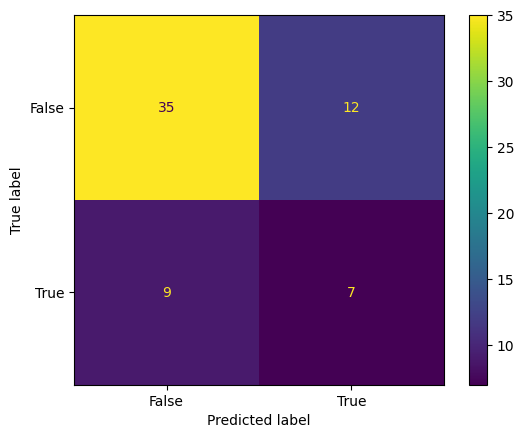

***********************************************
Random Forest ------------
ROCAUC score: 0.4993351063829788
Accuracy score: 0.7142857142857143
F1 score: 0.1
recall score: 0.0625
precision score: 0.25


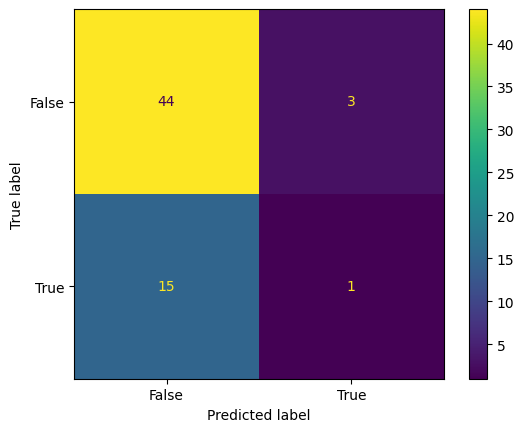

***********************************************


In [206]:
print("Decision Tree ------------")
pred_tree4, tree4, prob_tree4 = model_pred_fun(DecisionTreeClassifier(),X_train, y_train, X_test, y_test)
print("***********************************************")

print("Random Forest ------------")
pred_rfc2, rfc2, prob_rfc2 = model_pred_fun(RandomForestClassifier(),X_train, y_train, X_test, y_test)
print("***********************************************")

#print("XGBoost ----------------")
#pred_xgb2, xgb2, prob_xgb2 = model_pred_fun(xgb.XGBClassifier(),X_train, y_train, X_test, y_test)
#print("***********************************************")


Decision Tree with smoteOTE data------------
ROCAUC score: 0.5492021276595744
Accuracy score: 0.6349206349206349
F1 score: 0.34285714285714286
recall score: 0.375
precision score: 0.3157894736842105


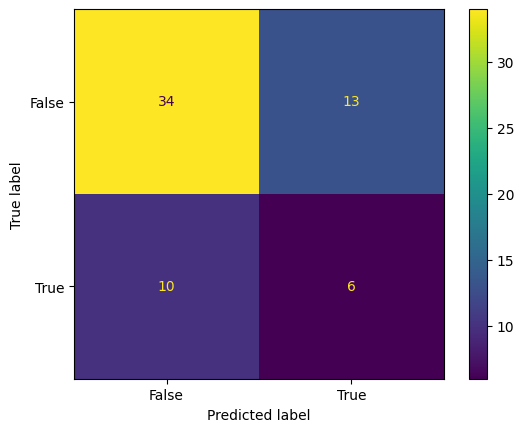

***********************************************
Decision Tree with oversampled data------------
ROCAUC score: 0.4966755319148936
Accuracy score: 0.5873015873015873
F1 score: 0.2777777777777778
recall score: 0.3125
precision score: 0.25


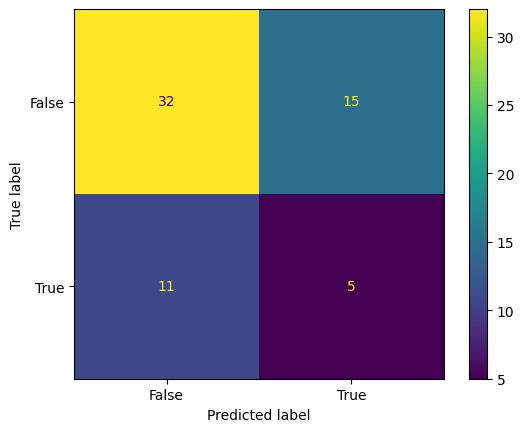

***********************************************
Decision Tree with Undersampled data------------
ROCAUC score: 0.4833776595744681
Accuracy score: 0.4444444444444444
F1 score: 0.339622641509434
recall score: 0.5625
precision score: 0.24324324324324326


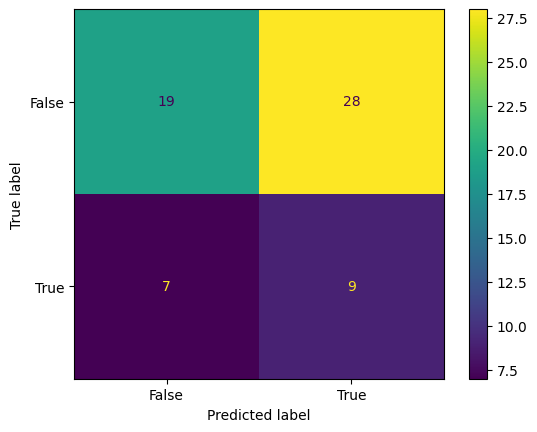

***********************************************
Decision Tree not sampled
ROCAUC score: 0.5186170212765957
Accuracy score: 0.6507936507936508
F1 score: 0.26666666666666666
recall score: 0.25
precision score: 0.2857142857142857


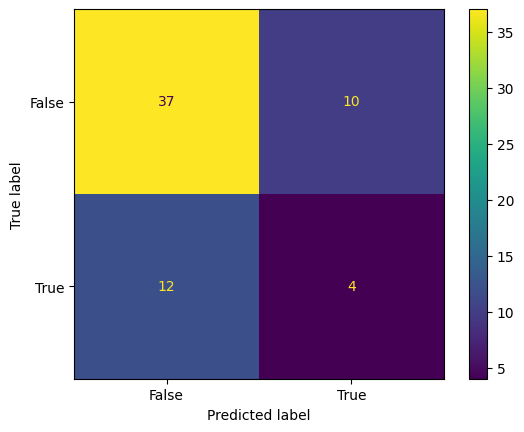

***********************************************
Random Forest with smoteOTE data------------
ROCAUC score: 0.46742021276595747
Accuracy score: 0.6666666666666666
F1 score: 0.08695652173913043
recall score: 0.0625
precision score: 0.14285714285714285


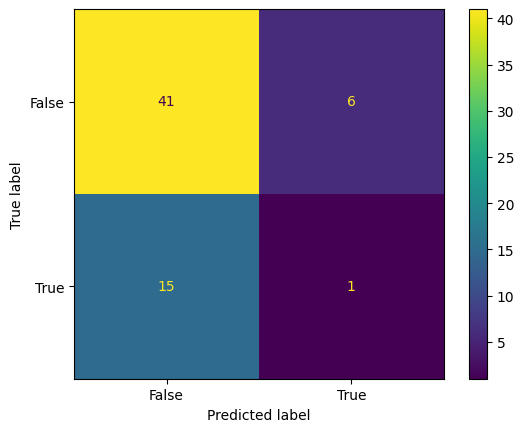

***********************************************
Random Forest with oversampled data------------
ROCAUC score: 0.5199468085106383
Accuracy score: 0.7142857142857143
F1 score: 0.18181818181818182
recall score: 0.125
precision score: 0.3333333333333333


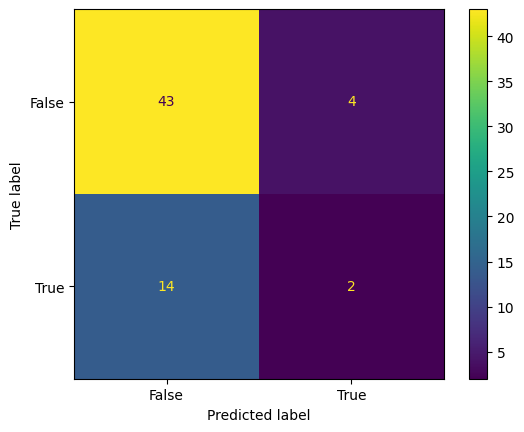

***********************************************
Random Forest with Undersampled data------------
ROCAUC score: 0.32646276595744683
Accuracy score: 0.3333333333333333
F1 score: 0.1923076923076923
recall score: 0.3125
precision score: 0.1388888888888889


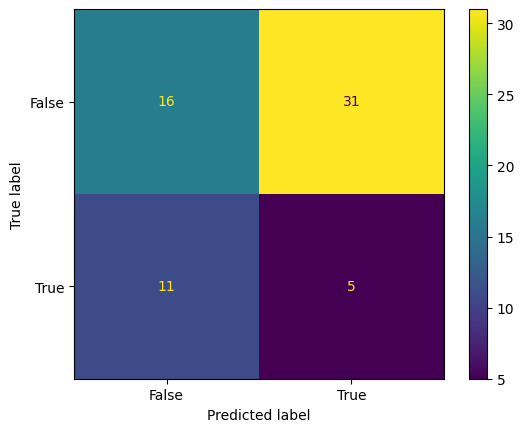

***********************************************
Random Forest not sampled
ROCAUC score: 0.5518617021276595
Accuracy score: 0.7619047619047619
F1 score: 0.21052631578947367
recall score: 0.125
precision score: 0.6666666666666666


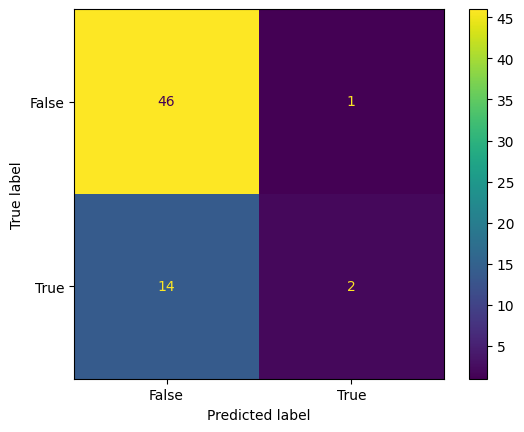

***********************************************


'\nprint("XGBoost with smoteOTE data------------")\npred_xgb1, xgb1, prob_xgb1 = model_pred_fun(xgb.XGBClassifier(),X_smote, y_smote, X_test, y_test)\nprint("***********************************************")\nprint("XGBoost with oversampled data------------")\npred_xgb1, xgb1, prob_xgb1 = model_pred_fun(xgb.XGBClassifier(),X_ros, y_ros, X_test, y_test)\nprint("***********************************************")\nprint("XGBoost with undersampled data------------")\npred_xgb3, xgb3, prob_xgb3 = model_pred_fun(xgb.XGBClassifier(),X_rus, y_rus, X_test, y_test)\nprint("***********************************************")\nprint("XGBoost not sampled")\npred_xgb2, xgb2, prob_xgb2 = model_pred_fun(xgb.XGBClassifier(),X_train, y_train, X_test, y_test)\nprint("***********************************************")\n\n'

In [207]:
print("Decision Tree with smoteOTE data------------")
pred_tree4, tree4, prob_tree4 = model_pred_fun(DecisionTreeClassifier(),X_smote, y_smote, X_test, y_test)
print("***********************************************")


print("Decision Tree with oversampled data------------")
pred_tree1, tree1, prob_tree1 = model_pred_fun(DecisionTreeClassifier(),X_ros, y_ros, X_test, y_test)
print("***********************************************")

print("Decision Tree with Undersampled data------------")
pred_tree3, tree3, prob_tree3 = model_pred_fun(DecisionTreeClassifier(),X_rus, y_rus, X_test, y_test)
print("***********************************************")

print("Decision Tree not sampled")
pred_tree2, tree2, prob_tree2 = model_pred_fun(DecisionTreeClassifier(),X_train, y_train, X_test, y_test)
print("***********************************************")

#-------------------------------------------
print("Random Forest with smoteOTE data------------")
pred_rfc4, rfc4, prob_rfc4 = model_pred_fun(RandomForestClassifier(),X_smote, y_smote, X_test, y_test)
print("***********************************************")

print("Random Forest with oversampled data------------")
pred_rfc1, rfc1, prob_rfc1 = model_pred_fun(RandomForestClassifier(),X_ros, y_ros, X_test, y_test)
print("***********************************************")

print("Random Forest with Undersampled data------------")
pred_rfc3, rfc3, prob_rfc3 = model_pred_fun(RandomForestClassifier(),X_rus, y_rus, X_test, y_test)
print("***********************************************")

print("Random Forest not sampled")
pred_rfc2, rfc2, prob_rfc2 = model_pred_fun(RandomForestClassifier(),X_train, y_train, X_test, y_test)
print("***********************************************")

#-------------------------------------------
"""
print("XGBoost with smoteOTE data------------")
pred_xgb1, xgb1, prob_xgb1 = model_pred_fun(xgb.XGBClassifier(),X_smote, y_smote, X_test, y_test)
print("***********************************************")
print("XGBoost with oversampled data------------")
pred_xgb1, xgb1, prob_xgb1 = model_pred_fun(xgb.XGBClassifier(),X_ros, y_ros, X_test, y_test)
print("***********************************************")
print("XGBoost with undersampled data------------")
pred_xgb3, xgb3, prob_xgb3 = model_pred_fun(xgb.XGBClassifier(),X_rus, y_rus, X_test, y_test)
print("***********************************************")
print("XGBoost not sampled")
pred_xgb2, xgb2, prob_xgb2 = model_pred_fun(xgb.XGBClassifier(),X_train, y_train, X_test, y_test)
print("***********************************************")

"""
#https://stackoverflow.com/questions/43162506/undefinedmetricwarning-f-score-is-ill-defined-and-being-set-to-0-0-in-labels-wi




In [208]:
from sklearn.model_selection import cross_validate

# define pipeline
steps = [ ('model',  DecisionTreeClassifier() )] #RandomForestClassifier() xgb.XGBClassifier()   DecisionTreeClassifier()
pipeline = Pipeline(steps=steps)
# evaluate pipeline

# split data into k smaller sets. train on k-1. Test on remaining 1 for performance. Avg results.
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=1) #shuffle=True
scoring = {'acc': 'accuracy',
           'prec_macro': 'precision_macro',
           'rec_micro': 'recall_macro',
          'f1': 'f1',
          'roc_auc': 'roc_auc'}
scores = cross_validate(pipeline, X_smote, y_smote, scoring=scoring, cv=cv, n_jobs=-1, return_estimator=True)
#print('Mean ROC AUC: %.3f' % np.mean(scores))

#print(scores.keys())

print("avg f1: " + str(scores['test_f1'].mean()))
print("avg recall: " + str(scores['test_rec_micro'].mean()))
print("avg precision: " + str(scores['test_prec_macro'].mean()))
print("-------------------------------")
print(scores['test_prec_macro'])
print("-------------------------------")
print(scores['test_rec_micro'])
print("-------------------------------")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

avg f1: 0.7378918384461335
avg recall: 0.7234534534534535
avg precision: 0.727957419944815
-------------------------------
[0.74342105 0.70509978 0.74776786 0.64519817 0.64823349 0.71637427
 0.74099617 0.72972973 0.76893939 0.73304348 0.58618012 0.75750916
 0.78461538 0.73984962 0.78078078 0.81448633 0.67567568 0.7202381
 0.68598485 0.8031401  0.77529762 0.73244642 0.74342105 0.63210445
 0.78840246]
-------------------------------
[0.74324324 0.7027027  0.74324324 0.64301802 0.64489489 0.71621622
 0.72972973 0.72972973 0.76651652 0.7012012  0.58108108 0.75675676
 0.78378378 0.73948949 0.78078078 0.81081081 0.67567568 0.71621622
 0.68430931 0.78265766 0.77027027 0.72972973 0.74324324 0.62912913
 0.78190691]
-------------------------------


In [209]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score



def myfun(sample_ind, sampler, sample_method, model, number_splits):
    """
    sample_ind: value of 'yes' or 'no'. Will the data need to be balanced in the pipeline
    sampler is sampling method: 'smote', 'oversample', 'undersample'
    corresponding sample method: SMOTE(), RandomOverSampler(), RandomUnderSampler()
    model will be: DecisionTreeClassifier(), RandomForestClassifier()
    number_splits is splits in kfold
    """

    if sample_ind == "no":
        # define pipeline
        steps = [ ('model',  model )] 
        pipeline = Pipeline(steps=steps)

    else:

        pipeline = ImbPipeline([
            (sampler, sample_method),  # Resampling inside the pipeline
            ('classifier', model)
        ])
    
    # Define cross-validation strategy
    cv = StratifiedKFold(n_splits=number_splits,  shuffle=True, random_state=1)
    scoring = {'acc': 'accuracy',
               'prec_macro': 'precision_macro',
               'rec_micro': 'recall_macro',
              'f1': 'f1',
              'roc_auc': 'roc_auc'}

    scores = cross_validate(pipeline, X_train, y_train, scoring=scoring, cv=cv, n_jobs=-1, return_estimator=True)


    print("avg f1: " + str(scores['test_f1'].mean()))
    print("avg recall: " + str(scores['test_rec_micro'].mean()))
    print("avg precision: " + str(scores['test_prec_macro'].mean()))
    print("-------------------------------")
    print(scores['test_prec_macro'])
    print("-------------------------------")
    print(scores['test_rec_micro'])
    print("-------------------------------")

    return scores


model = DecisionTreeClassifier()
print("*********************** DECISION TREE ***************")

print("SMOTE")
smote_scores = myfun('yes','smote', SMOTE(), model, 5)
print("************************************************")
print("Random Over Sample")
ros_scores = myfun('yes','oversample', RandomOverSampler(), model, 5)
print("************************************************")
print("Random Under Sample")
rus_scores = myfun('yes','undersample', RandomUnderSampler(), model, 5)
print("************************************************")
print("No Sampling/Balancing Method")
non_scores = myfun('no','smote', SMOTE(), model, 5)



model = RandomForestClassifier()
print("*********************** RANDOM FOREST ***************")

print("SMOTE")
smote_scores = myfun('yes', 'smote', SMOTE(), model, 5)
print("************************************************")
print("Random Over Sample")
ros_scores = myfun('yes','oversample', RandomOverSampler(), model, 5)
print("************************************************")
print("Random Under Sample")
rus_scores = myfun('yes','undersample', RandomUnderSampler(), model, 5)
print("************************************************")
print("No Sampling/Balancing Method")
non_scores = myfun('no','smote', SMOTE(), model, 5)


*********************** DECISION TREE ***************
SMOTE
avg f1: 0.325483682983683
avg recall: 0.5291250041250042
avg precision: 0.5235256616506616
-------------------------------
[0.49826389 0.58419958 0.53333333 0.44988345 0.55194805]
-------------------------------
[0.49801587 0.58419958 0.54158004 0.45530146 0.56652807]
-------------------------------
************************************************
Random Over Sample
avg f1: 0.27305875733461943
avg recall: 0.5018150018150018
avg precision: 0.5006798284780658
-------------------------------
[0.48641766 0.53860294 0.54824561 0.48024948 0.44988345]
-------------------------------
[0.48412698 0.54365904 0.54573805 0.48024948 0.45530146]
-------------------------------
************************************************
Random Under Sample
avg f1: 0.3786357786357787
avg recall: 0.5383097383097383
avg precision: 0.5305589692274502
-------------------------------
[0.51358234 0.59253247 0.53044872 0.5258467  0.49038462]
------------------

In [210]:
# saving the model I like best
#import pickle  

#with open("model_rus_randomForest_Top3.pkl", "wb") as f:
 #   pickle.dump(rfc3, f)

In [211]:
len(['Age_x', 'Age_y', 'LGBT_team', 'AficanAm_team', 'AsianAm_team',
       'Hispanic_team', 'Interracial_team', 'Disabled_team',
       'RealityShow_team', 'Friend_team', 'Family_team', 'Couple_or_Ex_team',
       'Married_team', 'Stranger_team', 'Female_team', 'Male_team',
       'Coed_team', 'Same_State', 'Avg_Age', 'Age_Diff'])

20

/Users/laurenshores/Documents/Data_Science_Projects/newenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/laurenshores/Documents/Data_Science_Projects/newenv/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
